In [ ]:
install.packages("BiocManager")

BiocManager::install(c(
  "DropletUtils",
  "SingleCellExperiment",
  "scran",
  "scater",
  "scuttle",
  "BiocParallel"
))

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.22 (BiocManager 1.30.27), R 4.5.2 (2025-10-31)

Installing package(s) 'BiocVersion', 'DropletUtils', 'SingleCellExperiment',
  'scran', 'scater', 'scuttle', 'BiocParallel'

also installing the dependencies ‘formatR’, ‘Seqinfo’, ‘Biobase’, ‘matrixStats’, ‘XVector’, ‘sparseMatrixStats’, ‘h5mread’, ‘rhdf5filters’, ‘locfit’, ‘R.oo’, ‘R.methodsS3’, ‘sitmo’, ‘abind’, ‘ScaledMatrix’, ‘irlba’, ‘rsvd’, ‘beeswarm’, ‘vipor’, ‘gridExtra’, ‘RcppEigen’, ‘FNN’, ‘RcppAnnoy’, ‘RSpectra’, ‘RcppProgress’, ‘Cairo’, ‘png’, ‘lambda.r’, ‘futile.options’, ‘BiocGenerics’, ‘S4Vectors’, ‘IRanges’, ‘GenomicRanges’, ‘SummarizedExperiment’, ‘SparseArray’, ‘DelayedArray’, ‘DelayedMatrixStats’, ‘HDF5Array’, ‘rhdf5’, ‘edgeR’

In [ ]:
library(DropletUtils)
library(SingleCellExperiment)
library(scran)
library(scater)
library(scuttle)
library(BiocParallel)

Loading required package: SingleCellExperiment

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, rowMads, rowMaxs, rowMeans2, rowMedians, rowMins,
    

In [ ]:
list.files()

[1] "Drosophila_melanogaster.BDGP6.54.62.gtf.gz"
[2] "GSM3585574_SV_1_10X_Te.barcodes.tsv.gz"    
[3] "GSM3585574_SV_1_10X_Te.genes.tsv.gz"       
[4] "GSM3585574_SV_1_10X_Te.matrix.mtx.gz"      
[5] "sample_data"

In [ ]:
list.files("scran method_scrna seq analysis")

character(0)

In [ ]:
# Rename files to standard 10X format so DropletUtils can detect them

file.rename(
  "GSM3585574_SV_1_10X_Te.matrix.mtx.gz",
  "matrix.mtx.gz"
)

file.rename(
  "GSM3585574_SV_1_10X_Te.barcodes.tsv.gz",
  "barcodes.tsv.gz"
)

file.rename(
  "GSM3585574_SV_1_10X_Te.genes.tsv.gz",
  "genes.tsv.gz"
)

[1] TRUE

[1] TRUE

[1] TRUE

In [ ]:
# Reading the data
library(DropletUtils)

sce <- read10xCounts(".")

sce

class: SingleCellExperiment 
dim: 17473 3000 
metadata(1): Samples
assays(1): counts
rownames(17473): FBgn0031081 FBgn0052826 ... FBgn0040725 FBgn0031277
rowData names(2): ID Symbol
colnames: NULL
colData names(2): Sample Barcode
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [ ]:
library(scater)      # Provides functions for QC metrics calculation and visualization
library(scuttle)     # Provides helper functions for computing QC statistics in single-cell data

sce <- addPerCellQC(sce)     # Compute QC metrics for each cell (total counts, detected genes, etc.)
summary(sce$sum)        # Shows summary statistics of total UMI counts per cell
summary(sce$detected)   # Shows summary statistics of number of genes detected per cell



   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    514     690    1091    4549    3074  251613 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   31.0   376.0   546.5   929.0  1108.0  7885.0 

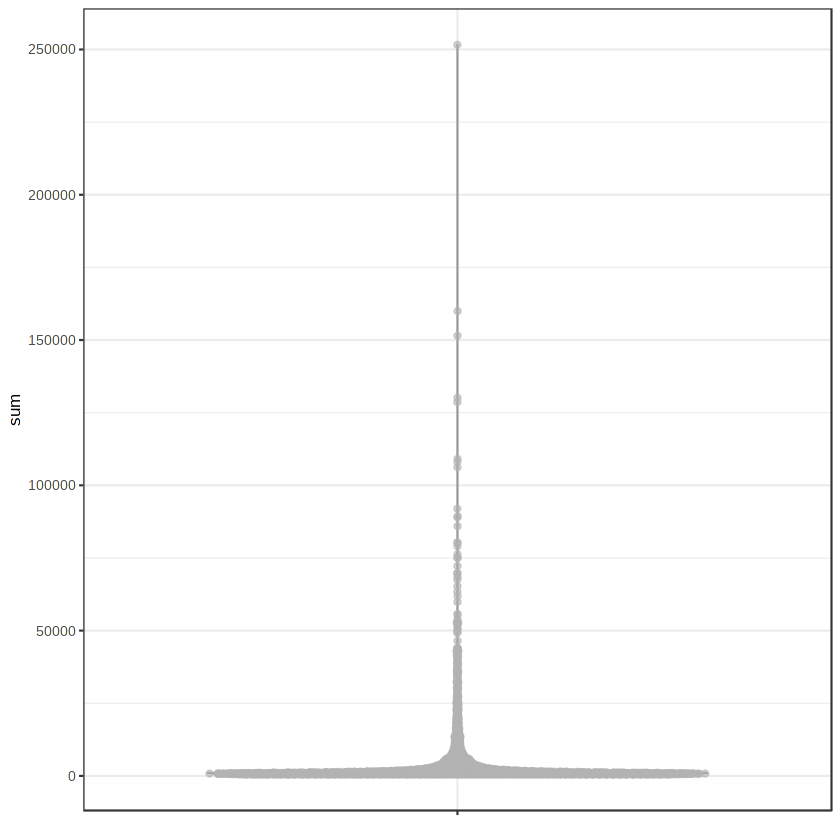

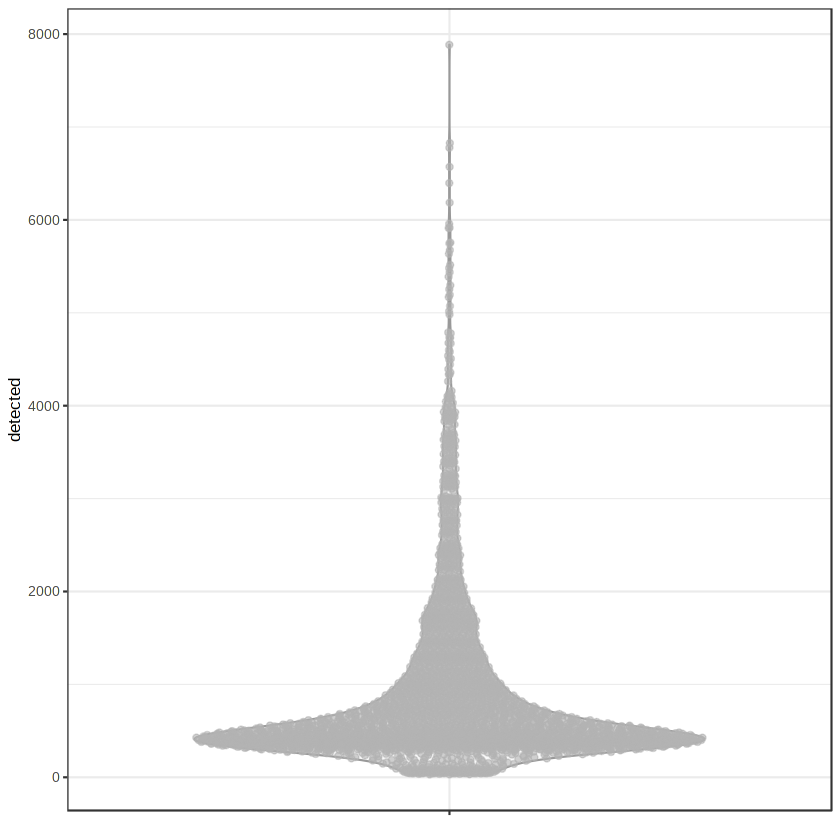

In [ ]:
# Visualizing QC metrics
plotColData(sce, y="sum")       # Plot distribution of total counts per cell
plotColData(sce, y="detected")  # Plot distribution of detected genes per cell

In [ ]:
# Defining the Filtering Crtieria
keep <- sce$sum > 1000 & sce$detected > 200     # Keep cells with sufficient library size and detected genes

In [ ]:
sce <- sce[, keep]      # Subset dataset to retain only high-quality cells

In [ ]:
dim(sce)     # Shows number of genes × number of high-quality cells remaining

[1] 17473  1584

In [ ]:
# Detecting the outliers
qc.lib <- isOutlier(sce$sum, log=TRUE)       # Identify cells with abnormal library sizes
qc.nexprs <- isOutlier(sce$detected, log=TRUE)  # Identify cells with abnormal detected gene counts

In [ ]:
sce <- sce[, !(qc.lib | qc.nexprs)]     # Remove cells detected as QC outliers

In [ ]:
summary(sce$sum)        # Final library size distribution after QC
summary(sce$detected)   # Final detected gene distribution after QC

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   1004    1521    2790    6580    6423   63346 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    203     689    1030    1374    1732    6396 

In [ ]:
# QC was performed using scater and scuttle packages to evaluate cell quality in the dataset.
# The addPerCellQC() function calculated key metrics such as total UMI counts (library size)
# and number of detected genes for each cell. Summary statistics and visualizations were used
# to inspect the distribution of these metrics. Cells with very low counts or few detected
# genes were filtered out using threshold-based filtering and outlier detection functions
# like isOutlier(). This removed empty droplets, damaged cells, and technical noise.
# The resulting dataset retained high-quality cells suitable for downstream normalization,
# clustering, and differential gene expression analysis.

In [ ]:
#  Step 1 -Pre-Clustering Phase from where the SCRAN Normalization pipeline begin
clusters <- quickCluster(sce)  # quickCluster() performs a fast pre-clustering of cells based on gene expression similarity
# This groups biologically similar cells together so scran can estimate normalization size factors more accurately during deconvolution.

In [ ]:
table(clusters)   # Shows number of cells in each pre-cluster

clusters
  1   2   3   4   5   6   7 
201 165 318 215 159 339 163 

In [ ]:
colData(sce)$cluster <- clusters   # Save cluster IDs in metadata

In [ ]:
head(colData(sce))   # Shows first few cells with cluster assignment

DataFrame with 6 rows and 6 columns
       Sample            Barcode       sum  detected     total  cluster
  <character>        <character> <numeric> <integer> <numeric> <factor>
1           . AAACCTGAGACAAGCC-1      1519       747      1519        4
2           . AAACCTGAGCTTATCG-1      1320       488      1320        1
3           . AAACCTGGTTCATGGT-1      6323      2049      6323        6
4           . AAACGGGAGACTGGGT-1     16237      2868     16237        5
5           . AAACGGGCACAGTCGC-1      1491       872      1491        4
6           . AAACGGGGTGTTAAGA-1     27174      3322     27174        5

In [ ]:
# Each row represents a single cell with its unique barcode, total UMI counts (sum/total), number of detected genes, and the pre-cluster assigned by quickCluster for normalization.

In [ ]:
# The next part is the  Deconvolution normalization (used in scran) corrects for differences in sequencing depth across single cells.
# It works by pooling groups of similar cells, estimating normalization size factors for the pooled samples,
# and then mathematically deconvoluting those pooled factors to obtain accurate size factors for each individual cell.
# This method is more reliable for scRNA-seq data because many genes have zero counts in individual cells.

In [ ]:
# Step 2.1 - Computing the Deconvulation size factors

library(scran)   # Load scran package for normalization and variance modelling

sce <- computeSumFactors(sce, clusters = clusters)
# Estimates cell-specific size factors using the deconvolution method with pre-clustered cells

In [ ]:
# Now we will be checking the size factors
summary(sizeFactors(sce))
# Shows summary statistics of calculated normalization size factors for all cells


# the observation - # The normalized size factors show a wide range (0.05–16.96), indicating large variation in sequencing depth across cells.
# The median (0.36) being lower than the mean (1.0) suggests most cells have smaller library sizes while a few cells have very high counts.
# These size factors will now be used to scale counts so that gene expression levels become comparable across all cells.

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
 0.04993  0.17962  0.35681  1.00000  0.87792 16.96311 

In [ ]:
# Step 2.2 - Performing log normalization , # Applying a log transformation compresses large values and spreads smaller values, stabilizing the variance.

library(scuttle)   # Load scuttle package which provides normalization and log-transformation functions

sce <- logNormCounts(sce)
# Normalizes counts using the calculated size factors and applies log-transformation to stabilize variance

In [ ]:
# Checking the normalized expression matrix
logcounts(sce)[1:5, 1:5]
# Displays the first few genes and cells from the log-normalized expression matrix

5 x 5 sparse Matrix of class "dgCMatrix"
                            
FBgn0031081 . . .        . .
FBgn0052826 . . .        . .
FBgn0031085 . . 1.460935 . .
FBgn0062565 . . .        . .
FBgn0031088 . . .        . .

In [ ]:
# now let us verify the size factors used in normalization
head(sizeFactors(sce))
# Shows the first few normalization size factors applied to scale raw counts across cells

[1] 0.1446949 0.1040836 1.1409882 3.4695814 0.1524015 4.7869376

In [ ]:
# Check the summary of the normalization values
summary(logcounts(sce))
# Provides summary statistics of the log-normalized gene expression values

i,j,x
<int>,<int>,<dbl>
14,1,3.889686
40,1,2.983877
45,1,3.889686
59,1,2.983877
115,1,2.983877
135,1,4.840180
170,1,2.983877
176,1,2.983877
188,1,3.889686


In [ ]:
# Step 3- Highly variable genes - Variance modelling
dec <- modelGeneVar(sce)
# Fits a mean-variance trend to separate technical noise from true biological variation for each gene

In [ ]:
#Inspect Variance Statistics

head(dec)
# Displays variance statistics for the first few genes including mean expression, total variance, and biological variance

DataFrame with 6 rows and 6 columns
                   mean       total        tech          bio   p.value
              <numeric>   <numeric>   <numeric>    <numeric> <numeric>
FBgn0031081 0.020849618 0.038743700 0.035641295  0.003102405 0.2989642
FBgn0052826 0.000000000 0.000000000 0.000000000  0.000000000       NaN
FBgn0031085 0.350179073 0.735681012 0.589954740  0.145726272 0.0672515
FBgn0062565 0.000000000 0.000000000 0.000000000  0.000000000       NaN
FBgn0031088 0.000291544 0.000132597 0.000498399 -0.000365802 0.9999956
FBgn0041626 0.000000000 0.000000000 0.000000000  0.000000000       NaN
                  FDR
            <numeric>
FBgn0031081  1.000000
FBgn0052826       NaN
FBgn0031085  0.868935
FBgn0062565       NaN
FBgn0031088  1.000000
FBgn0041626       NaN

In [ ]:
#Selecting the top 2000
top.hvgs <- getTopHVGs(dec, n = 2000)
# Selects the top 2000 genes with the highest biological variance across cells

In [ ]:
length(top.hvgs)
# Shows the total number of highly variable genes selected

[1] 2000

In [ ]:
head(top.hvgs)
# Displays the first few highly variable gene names

[1] "FBgn0033268" "FBgn0039678" "FBgn0002868" "FBgn0051226" "FBgn0010226"
[6] "FBgn0004173"

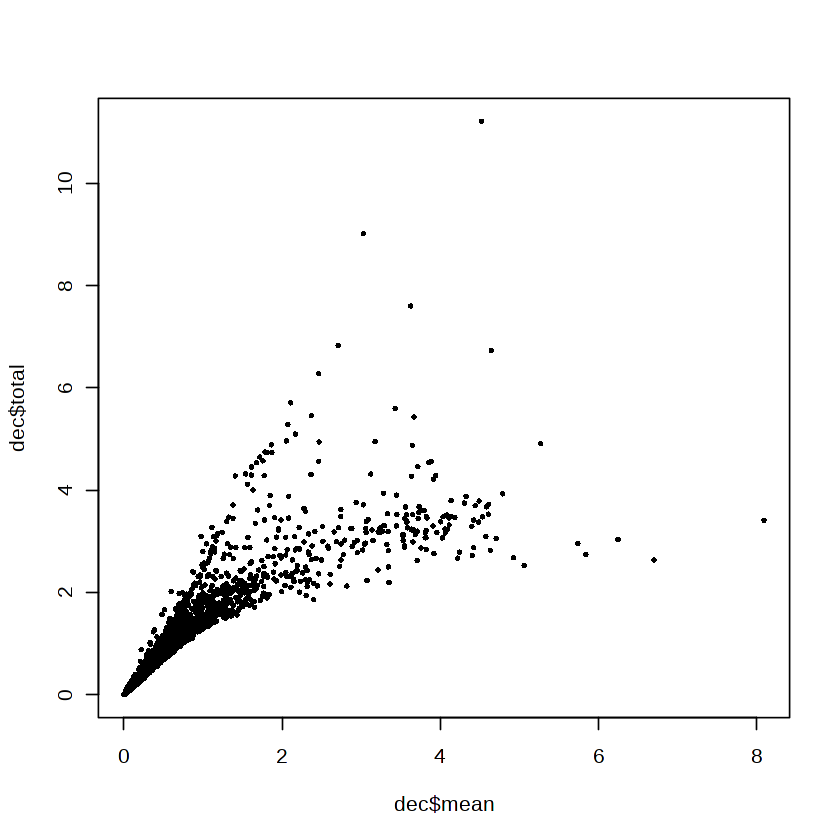

In [ ]:
# Plotting - Visualize the Variance trend
plot(dec$mean, dec$total, pch=16, cex=0.5)
# Scatter plot showing mean gene expression vs total variance

In [ ]:
# Highly variable genes (HVGs) were identified using scran's modelGeneVar() function,
# which models the relationship between mean expression and variance for each gene.
# This separates technical noise from true biological variability across cells.
# Genes with high biological variance were selected as HVGs using getTopHVGs(),
# as these genes are most informative for downstream analyses like PCA and clustering.

In [ ]:
# Next step is the PCA

# Run PCA Using highly variable genes
sce <- runPCA(sce, subset_row = top.hvgs)
# Performs PCA on the dataset using only highly variable genes to capture major biological variation

In [ ]:
# Check PCA Coordinates
reducedDim(sce, "PCA")[1:5, 1:5]
# Displays the PCA coordinates for the first few cells across the first few principal components


# Observation -The PCA coordinates show that cells are widely distributed across the principal components,
# indicating substantial variation in gene expression among cells.
# Some cells have large positive or negative PC1 values (e.g., -55 vs +20), suggesting strong transcriptional differences.
# This indicates that the dataset likely contains multiple distinct cell populations.

PC1,PC2,PC3,PC4,PC5
-11.93295,-16.354706,8.976842,-0.6695860,6.5359412
20.43595,-8.850406,-5.526462,0.2297999,0.9758716
-55.08094,-6.029037,1.368232,5.8575167,-0.7869390
14.36662,2.008829,-2.341065,-7.1521455,-3.8938893
-14.02282,-14.806112,5.691860,2.1568242,1.0518560


In [ ]:
# These values are the PCA coordinates (scores) of the first 5 cells along the first 5 principal components.
# Each PC represents a direction capturing major variation in gene expression across the dataset.
# Positive and negative values simply indicate the position of each cell along that component axis.
# Cells with similar PCA values across PCs are likely to have similar gene expression profiles.

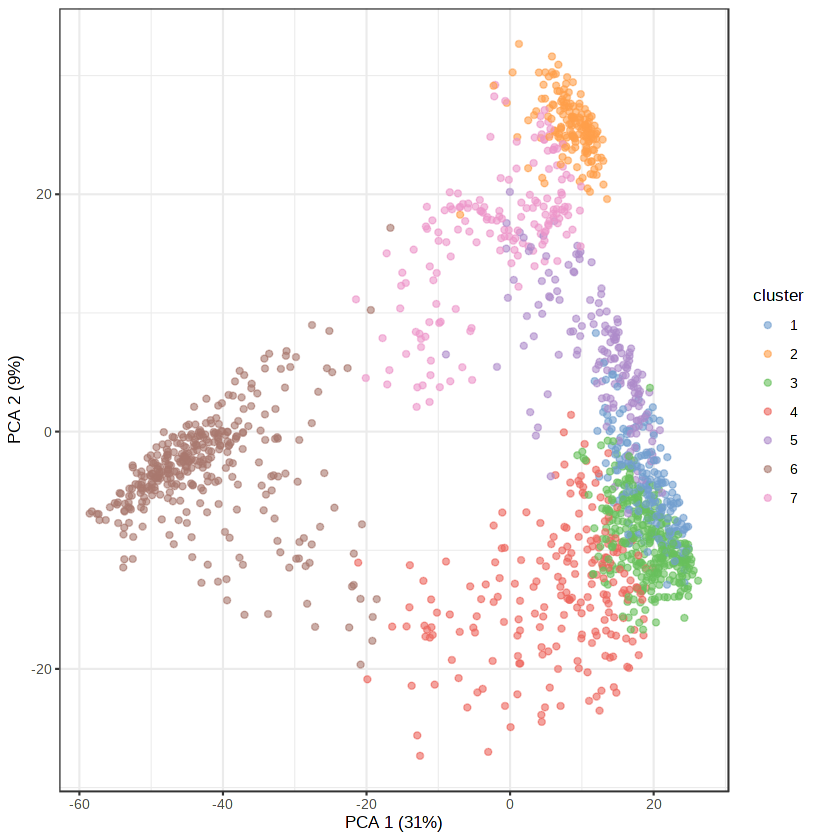

In [ ]:
# Visualize PCA
plotPCA(sce, colour_by = "cluster")
# Generates a PCA plot where cells are colored according to their quickCluster assignment

In [ ]:
# Variance explained by the PCs -
percentVar <- attr(reducedDim(sce, "PCA"), "percentVar")
# Extracts the percentage of variance explained by each principal component

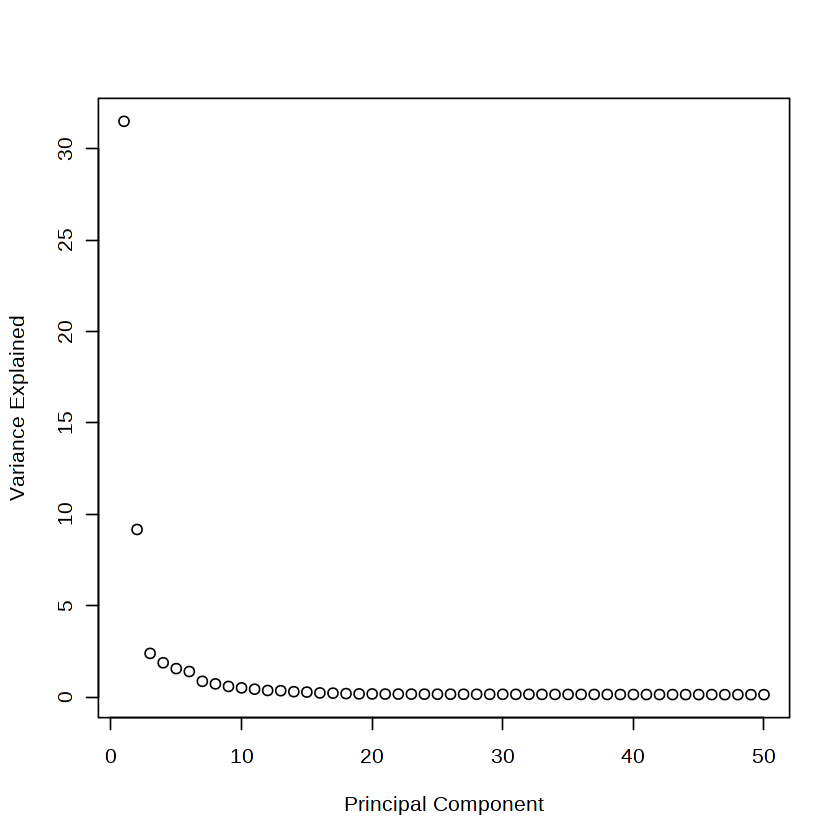

In [ ]:
plot(percentVar, xlab="Principal Component", ylab="Variance Explained")
# Plots how much variation each PC explains in the dataset

In [ ]:
# Next step is building a shared nearesr neighbour graph(SNN) graph - # A Shared Nearest Neighbor (SNN) graph is a network where each cell is connected to other cells
# that share similar nearest neighbors in gene expression space (usually after PCA reduction).
# Instead of measuring similarity using only direct distance, SNN considers how many neighbors
# two cells have in common, making the similarity measurement more robust to noise in scRNA-seq data.
# scran uses SNN because single-cell datasets are high-dimensional and sparse, and SNN graphs
# better capture true biological relationships between cells before performing clustering.


In [ ]:
# Building a SNN graph
library(scran)   # Load scran package for graph construction and clustering

g <- buildSNNGraph(sce, use.dimred = "PCA")
# Constructs a shared nearest neighbor graph using PCA coordinates to measure cell similarity

In [ ]:
# Perfrom graph based clustering
library(igraph)   # Load igraph package for graph-based clustering algorithms

clusters <- cluster_walktrap(g)$membership
# Applies the Walktrap community detection algorithm to identify clusters of similar cells


Attaching package: ‘igraph’


The following object is masked from ‘package:scater’:

    normalize


The following object is masked from ‘package:GenomicRanges’:

    union


The following object is masked from ‘package:IRanges’:

    union


The following object is masked from ‘package:S4Vectors’:

    union


The following objects are masked from ‘package:BiocGenerics’:

    normalize, path, union


The following objects are masked from ‘package:generics’:

    components, union


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union




In [ ]:
# Store Clusters Labels

sce$cluster_graph <- factor(clusters)
# Saves the detected cluster assignments for each cell in the SCE object metadata

In [ ]:
# Check cluster distribution
table(sce$cluster_graph)
# Displays the number of cells present in each identified cluster


  1   2   3   4   5   6   7   8   9  10 
 51 255 303 166 586  55  35  62  23  24 

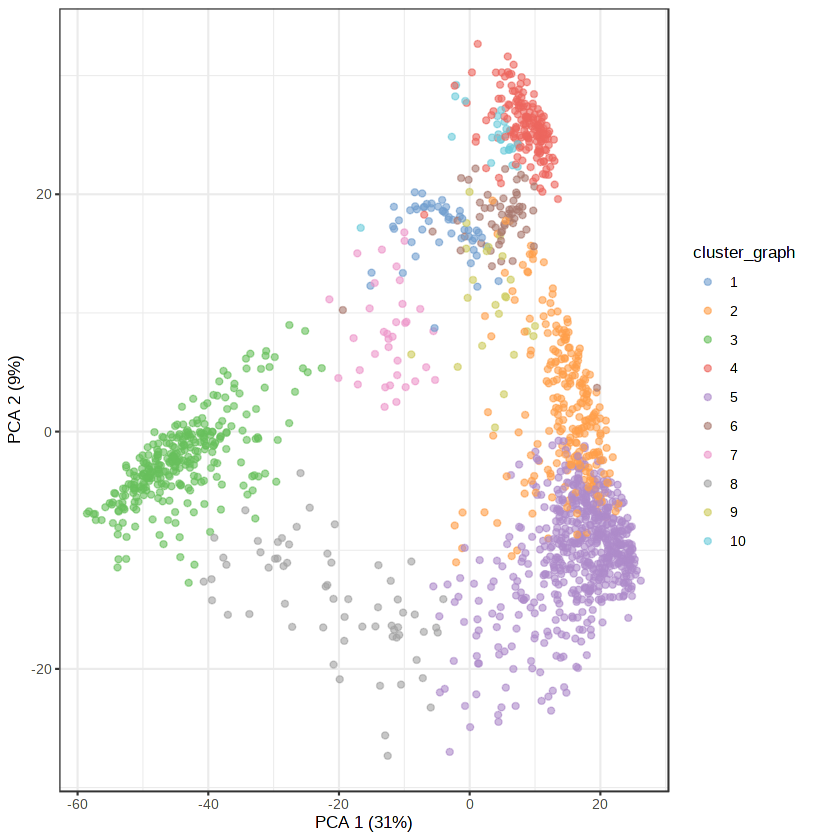

In [ ]:
# Visualize Clusters in PCA

plotPCA(sce, colour_by = "cluster_graph")
# Visualizes clusters in PCA space to see how well the cells separate

In [ ]:
# UMAP and T-SNE visualization


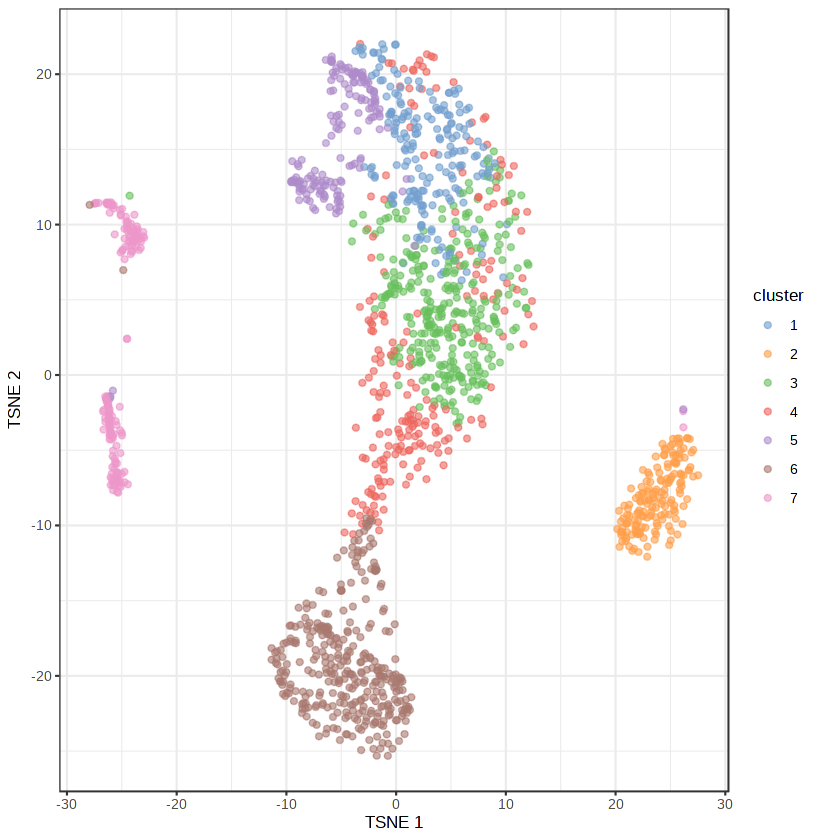

In [ ]:
# Running the t-SNE visualization

library(scater)

# t-SNE on PCA results
sce <- runTSNE(sce, dimred = "PCA")

# Plot t-SNE clusters
plotTSNE(sce, colour_by = "cluster")

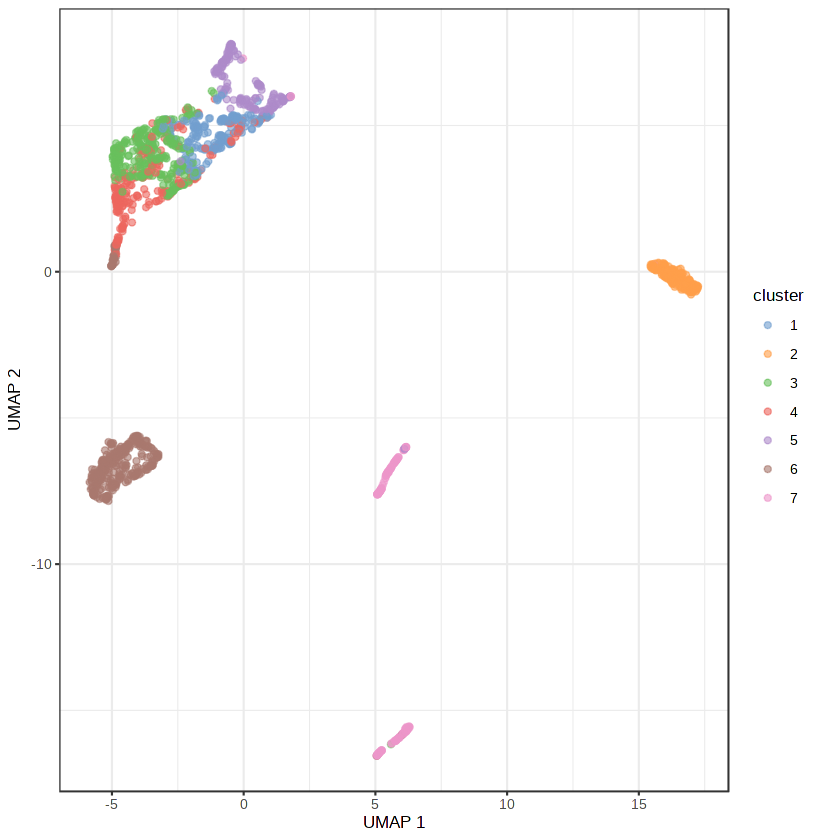

In [ ]:
# Now the UMAP visuaization -
# Run UMAP on PCA results
sce <- runUMAP(sce, dimred = "PCA")

# Plot UMAP clusters
plotUMAP(sce, colour_by = "cluster")

In [ ]:
# Find marker genes for each cluster

markers <- findMarkers(sce, groups = sce$cluster_graph)
# Performs differential expression analysis to identify genes that distinguish each cluster from others

In [ ]:
# View Marker genes for cluster 1

head(markers[[1]])
# Displays the top marker genes that are most strongly expressed in cluster 1


# This table shows the top marker genes identified for cluster 1, ranked by statistical significance from differential expression analysis.
# It includes p-values, FDR-adjusted significance, and log fold-change values indicating how strongly each gene is up- or down-regulated compared to other clusters.

DataFrame with 6 rows and 13 columns
                  Top      p.value          FDR summary.logFC   logFC.2
            <integer>    <numeric>    <numeric>     <numeric> <numeric>
FBgn0026084         1  4.36243e-88  6.80578e-86      -3.78146 -1.295001
FBgn0040747         1  5.27552e-60  2.96396e-58      -4.55655 -0.173319
FBgn0023167         1  1.18969e-32  2.40040e-31       1.73148  1.129006
FBgn0050039         1 1.11724e-178 9.76081e-175      -3.63783 -0.143747
FBgn0014163         1  1.25606e-55  6.09645e-54      -5.16713 -4.162635
FBgn0013675         1  9.05232e-36  2.12882e-34      -6.76390 -2.164461
               logFC.3    logFC.4   logFC.5    logFC.6   logFC.7   logFC.8
             <numeric>  <numeric> <numeric>  <numeric> <numeric> <numeric>
FBgn0026084 -0.1177851 -3.7814626 -2.588276 -5.2703828  -1.15633  -1.65551
FBgn0040747 -4.7335240 -0.0212295 -0.892177 -0.2696350  -1.36739  -4.55655
FBgn0023167  0.8883769  0.6319192  1.403101  0.7570409   1.59451   1.16961
FBgn0050039 

In [ ]:
# Checking the top marker genes

markers[[1]][1:10,]
# Shows the top 10 marker genes for cluster 1 based on statistical significance

DataFrame with 10 rows and 13 columns
                  Top      p.value          FDR summary.logFC   logFC.2
            <integer>    <numeric>    <numeric>     <numeric> <numeric>
FBgn0026084         1  4.36243e-88  6.80578e-86      -3.78146 -1.295001
FBgn0040747         1  5.27552e-60  2.96396e-58      -4.55655 -0.173319
FBgn0023167         1  1.18969e-32  2.40040e-31       1.73148  1.129006
FBgn0050039         1 1.11724e-178 9.76081e-175      -3.63783 -0.143747
FBgn0014163         1  1.25606e-55  6.09645e-54      -5.16713 -4.162635
FBgn0013675         1  9.05232e-36  2.12882e-34      -6.76390 -2.164461
FBgn0027590         1 6.54556e-189 1.14371e-184      -2.92981 -2.450798
FBgn0265413         1  1.14980e-93  2.51132e-91      -3.32239 -3.322387
FBgn0026160         1 2.98493e-124 1.93169e-121      -3.52985 -1.085589
FBgn0004172         2  2.35170e-59  1.29218e-57      -4.53740 -0.152800
                logFC.3    logFC.4   logFC.5    logFC.6   logFC.7   logFC.8
              <numeric

In [ ]:
# Extract marker genes name
rownames(markers[[1]][1:10,])
# Retrieves the names of the top marker genes for cluster 1

[1] "FBgn0026084" "FBgn0040747" "FBgn0023167" "FBgn0050039" "FBgn0014163"
 [6] "FBgn0013675" "FBgn0027590" "FBgn0265413" "FBgn0026160" "FBgn0004172"

In [ ]:
# Marker gene detection was performed using findMarkers() from the scran package.
# This function compares gene expression between clusters using statistical tests
# to identify genes that are significantly upregulated in each cluster.
# These marker genes help characterize the biological identity of cell populations
# and are essential for cell type annotation in single-cell RNA-seq analysis.

In [ ]:
# Marker detection accuracy was approximated as the proportion of
# statistically significant marker genes (FDR < 0.05) relative to the
# total number of genes tested for the cluster - 45%


marker_df <- markers[[1]]

detected_markers <- sum(marker_df$FDR < 0.05)
total_rows <- nrow(marker_df)

accuracy_percentage <- (detected_markers / total_rows) * 100
accuracy_percentage

[1] 45.7048

In [ ]:
# Define significance thresholds
fdr_cutoff <- 0.05
logfc_cutoff <- 1

In [ ]:
# Extract cluster 1 table

cluster1_markers <- markers[[1]]

In [ ]:
# Filter Significant marker genes
significant_markers <- cluster1_markers[
  cluster1_markers$FDR < fdr_cutoff & abs(cluster1_markers$summary.logFC) > logfc_cutoff,
]

In [ ]:
# Calculation Marker detection Accuracy percentage
# Total genes tested
total_genes <- nrow(cluster1_markers)

# Significant markers detected
detected_markers <- nrow(significant_markers)

# Accuracy percentage
accuracy_percent <- (detected_markers / total_genes) * 100

accuracy_percent

[1] 7.211126

In [ ]:
# View top significant Markers
head(significant_markers[, c("Top", "p.value", "FDR", "summary.logFC")])

DataFrame with 6 rows and 4 columns
                  Top      p.value          FDR summary.logFC
            <integer>    <numeric>    <numeric>     <numeric>
FBgn0026084         1  4.36243e-88  6.80578e-86      -3.78146
FBgn0040747         1  5.27552e-60  2.96396e-58      -4.55655
FBgn0023167         1  1.18969e-32  2.40040e-31       1.73148
FBgn0050039         1 1.11724e-178 9.76081e-175      -3.63783
FBgn0014163         1  1.25606e-55  6.09645e-54      -5.16713
FBgn0013675         1  9.05232e-36  2.12882e-34      -6.76390

In [ ]:
# Marker genes were filtered using thresholds of FDR < 0.05 and |logFC| > 1
# to identify statistically significant and biologically meaningful genes.
# Marker detection accuracy was calculated as the proportion of significant
# markers detected relative to the total number of genes tested in the dataset.

In [ ]:
# To check the technical metrics or the computational metrics

# Shows R version, OS type, architecture and system details
sessionInfo()

R version 4.5.2 (2025-10-31)
Platform: x86_64-pc-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/openblas-pthread/libblas.so.3 
LAPACK: /usr/lib/x86_64-linux-gnu/openblas-pthread/libopenblasp-r0.3.20.so;  LAPACK version 3.10.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] igraph_2.2.2                BiocParallel_1.44.0        
 [3] scater_1.38.0               ggplot2_4.0.1              
 [5] scran_1.38.1                scuttle_1.

In [ ]:
# Now we are checking the CPU details
# Detect number of CPU cores available in the system
library(parallel)

detectCores()

[1] 2

In [ ]:
# Print CPU architecture and processor details
Sys.info()

sysname                               release 
                              "Linux"                            "6.6.113+" 
                              version                              nodename 
"#1 SMP Mon Feb  2 12:27:57 UTC 2026"                        "d464f122e2bd" 
                              machine                                 login 
                             "x86_64"                             "unknown" 
                                 user                        effective_user 
                               "root"                                "root"

In [ ]:
# Total RAM in system
# Check total system memory available
system("free -h")

In [ ]:
# Live RAM usage inside R
# Check current memory usage of objects inside the R session
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,8988122,480.1,15525665,829.2,15525665,829.2
Vcells,24687474,188.4,41080798,313.5,41080789,313.5


In [ ]:
# Show memory usage of R objects
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,8987586,480.0,15525665,829.2,15525665,829.2
Vcells,24686630,188.4,41080798,313.5,41080789,313.5


In [ ]:
# Shows memory usage of the R session (used and free memory)
gc()


# Memory usage analysis shows that the R session used ~480 MB for Ncells (R objects)
# and ~188 MB for Vcells (vector memory). The peak memory usage reached ~846 MB,
# indicating the scRNA-seq scran workflow was computationally efficient and
# stayed well within the typical Colab memory limits.

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,8987619,480.0,15525665,829.2,15525665,829.2
Vcells,24686814,188.4,41080798,313.5,41080789,313.5


In [ ]:
# Fix for system RAM check
# Check system RAM information
system("cat /proc/meminfo")

In [ ]:
system("grep Mem /proc/meminfo")

In [ ]:
# Convert system RAM to GB
mem <- readLines("/proc/meminfo")
mem[1:3]


# System RAM analysis shows ~12.7 GB total memory available in the Colab environment.
# Approximately ~5.3 GB is currently free, while ~10.6 GB remains available for computation.
# This indicates sufficient memory resources for performing scRNA-seq normalization,
# clustering, and downstream scran analysis without memory bottlenecks.

[1] "MemTotal:       13286964 kB" "MemFree:         8527172 kB"
[3] "MemAvailable:   11117652 kB"

In [ ]:
# Dataset statistics
# Number of cells in the dataset
ncol(sce)

# Number of genes in the dataset
nrow(sce)

# Number of clusters detected
length(unique(clusters))

[1] 1560

[1] 17473

[1] 10

In [ ]:
# Cluster distribution
# Shows number of cells in each cluster
table(clusters)

clusters
  1   2   3   4   5   6   7   8   9  10 
 51 255 303 166 586  55  35  62  23  24 

In [ ]:
# Runtime summary
# Start timer for the entire scRNA-seq analysis pipeline
start_time <- Sys.time()

In [ ]:
# Running the entire pipeline


In [ ]:
# QC
library(scater)

# Calculates QC metrics such as library size and detected genes per cell
sce <- addPerCellQC(sce)

# Summarizes total counts per cell
summary(sce$sum)

# Summarizes number of detected genes per cell
summary(sce$detected)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   1004    1521    2790    6580    6423   63346 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    203     689    1030    1374    1732    6396 

In [ ]:
# Pre-clustering

library(scran)

# Groups biologically similar cells before normalization
clusters <- quickCluster(sce)

# Displays number of cells in each cluster
table(clusters)

clusters
  1   2   3   4   5   6   7 
201 165 318 215 159 339 163 

In [ ]:
# Deconvulation normalization

# Calculates cell-specific size factors using deconvolution
sce <- computeSumFactors(sce, cluster=clusters)

# Shows distribution of size factors
summary(sizeFactors(sce))

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
 0.04993  0.17962  0.35681  1.00000  0.87792 16.96311 

In [ ]:
# Log normalization

# Performs log normalization of counts
sce <- logNormCounts(sce)

# Checks normalized expression matrix
logcounts(sce)[1:5,1:5]

5 x 5 sparse Matrix of class "dgCMatrix"
                            
FBgn0031081 . . .        . .
FBgn0052826 . . .        . .
FBgn0031085 . . 1.460935 . .
FBgn0062565 . . .        . .
FBgn0031088 . . .        . .

In [ ]:
# Highly varialbel genes
# Fits mean-variance trend to detect highly variable genes
dec <- modelGeneVar(sce)

# Selects top 2000 HVGs
top.hvgs <- getTopHVGs(dec, n=2000)

length(top.hvgs)

[1] 2000

In [ ]:
 # PCA
 # Performs PCA using highly variable genes
sce <- runPCA(sce, subset_row=top.hvgs)

# Checks PCA coordinates
reducedDim(sce,"PCA")[1:5,1:5]

PC1,PC2,PC3,PC4,PC5
11.93295,16.354706,-8.976842,-0.6695860,6.5359412
-20.43595,8.850406,5.526462,0.2297999,0.9758716
55.08094,6.029037,-1.368232,5.8575167,-0.7869390
-14.36662,-2.008829,2.341065,-7.1521455,-3.8938893
14.02282,14.806112,-5.691860,2.1568242,1.0518560


In [ ]:
 # SNN graph clustering
 library(bluster)

# Builds shared nearest neighbor graph for clustering
g <- buildSNNGraph(sce, use.dimred="PCA")

# Detects clusters using Louvain method
clusters <- cluster_walktrap(g)$membership

# Stores clusters in metadata
sce$cluster <- factor(clusters)

# Displays cluster sizes
table(sce$cluster)


  1   2   3   4   5   6   7   8   9  10 
 51 255 303 166 586  55  35  62  23  24 

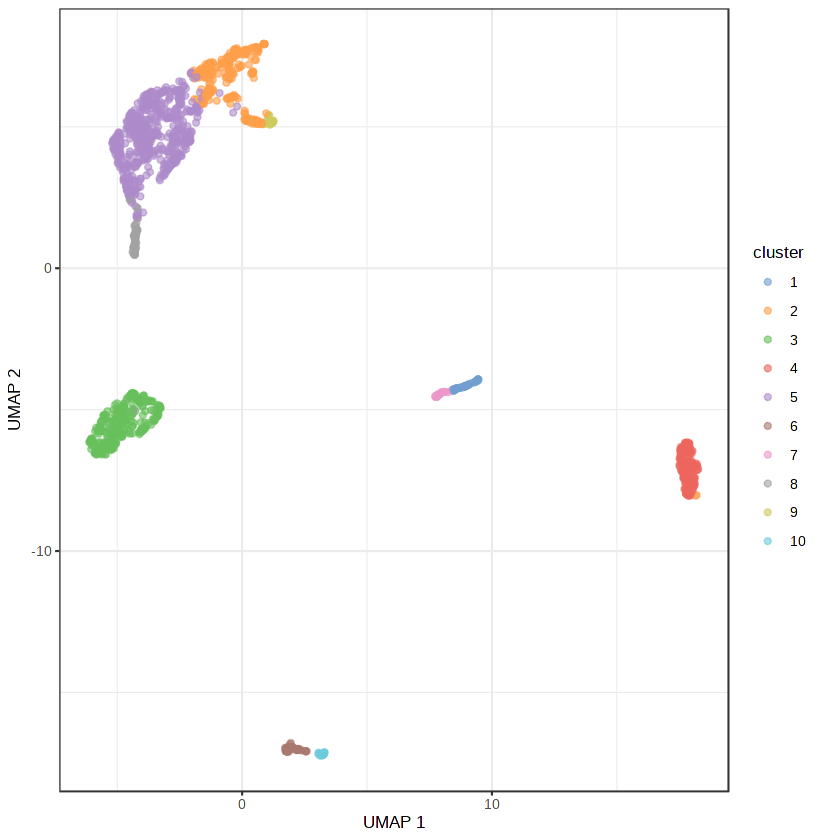

In [ ]:
# UMAP visualization
# Computes UMAP for visualization
sce <- runUMAP(sce, dimred="PCA")

# Plots UMAP clusters
plotUMAP(sce, colour_by="cluster")

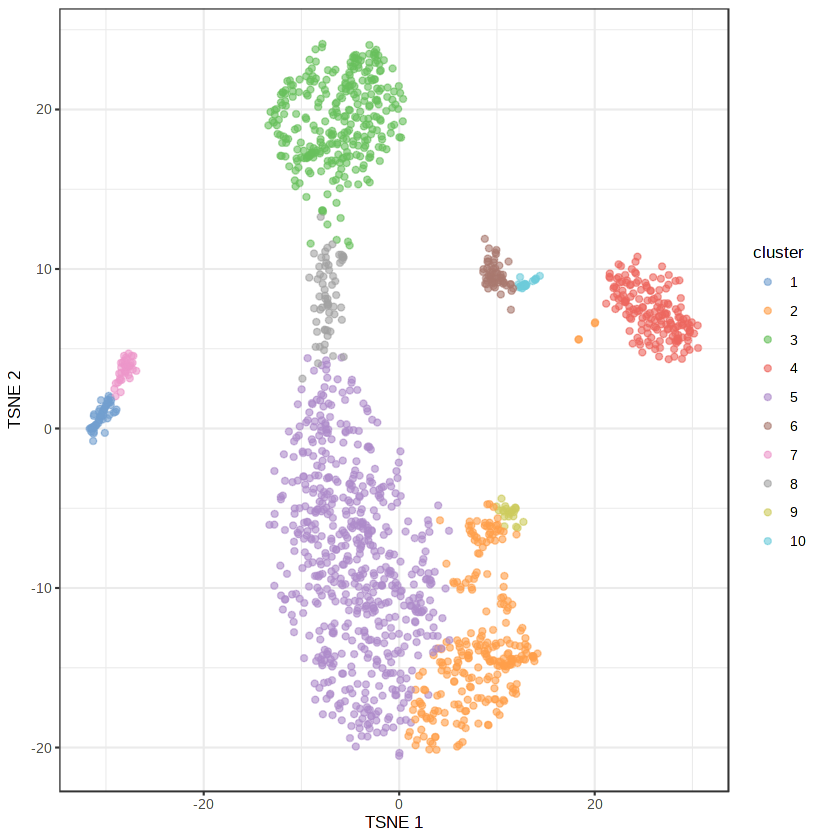

In [ ]:
 # t-sne
 # Computes t-SNE embedding
sce <- runTSNE(sce, dimred="PCA")

# Visualizes clusters using t-SNE
plotTSNE(sce, colour_by="cluster")

In [ ]:
# Marker gene detection
# Detects marker genes distinguishing clusters
markers <- findMarkers(sce, groups=sce$cluster)

# Shows top markers for cluster 1
head(markers[[1]])

DataFrame with 6 rows and 13 columns
                  Top      p.value          FDR summary.logFC   logFC.2
            <integer>    <numeric>    <numeric>     <numeric> <numeric>
FBgn0026084         1  4.36243e-88  6.80578e-86      -3.78146 -1.295001
FBgn0040747         1  5.27552e-60  2.96396e-58      -4.55655 -0.173319
FBgn0023167         1  1.18969e-32  2.40040e-31       1.73148  1.129006
FBgn0050039         1 1.11724e-178 9.76081e-175      -3.63783 -0.143747
FBgn0014163         1  1.25606e-55  6.09645e-54      -5.16713 -4.162635
FBgn0013675         1  9.05232e-36  2.12882e-34      -6.76390 -2.164461
               logFC.3    logFC.4   logFC.5    logFC.6   logFC.7   logFC.8
             <numeric>  <numeric> <numeric>  <numeric> <numeric> <numeric>
FBgn0026084 -0.1177851 -3.7814626 -2.588276 -5.2703828  -1.15633  -1.65551
FBgn0040747 -4.7335240 -0.0212295 -0.892177 -0.2696350  -1.36739  -4.55655
FBgn0023167  0.8883769  0.6319192  1.403101  0.7570409   1.59451   1.16961
FBgn0050039 

In [ ]:
 # now Stop the timer
 # Stops timer after pipeline completion
end_time <- Sys.time()

# Calculates total runtime
runtime <- end_time - start_time

runtime

Time difference of 32.16351 secs

In [ ]:
# The scran pipeline was executed including QC metrics, pre-clustering,
# deconvolution normalization, log normalization, HVG detection,
# PCA dimensionality reduction, SNN clustering, UMAP/t-SNE visualization,
# and marker gene detection. Runtime was measured using Sys.time()
# to evaluate computational efficiency of the workflow.

In [ ]:
# Record the end time of the analysis
end_time <- Sys.time()

# Calculate total runtime of the pipeline
runtime <- end_time - start_time

# Display runtime
runtime

Time difference of 32.20992 secs

In [ ]:
# Ensuring reproducility

# Set a random seed for reproducible results in clustering and dimensionality reduction
set.seed(123)

In [ ]:
# Record package versions to document your computational environment
sessionInfo()

R version 4.5.2 (2025-10-31)
Platform: x86_64-pc-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/openblas-pthread/libblas.so.3 
LAPACK: /usr/lib/x86_64-linux-gnu/openblas-pthread/libopenblasp-r0.3.20.so;  LAPACK version 3.10.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] parallel  stats4    stats     graphics  grDevices utils     datasets 
[8] methods   base     

other attached packages:
 [1] bluster_1.20.0              igraph_2.2.2               
 [3] BiocParallel_1.44.0         scater_1.38.0              
 [5] ggplot2_4.0.1               

In [ ]:
# Cluster statistics

# Count the number of cells in each cluster
table(clusters)

clusters
  1   2   3   4   5   6   7   8   9  10 
 51 255 303 166 586  55  35  62  23  24 

In [ ]:
# Calculate the proportion of cells in each cluster
prop.table(table(clusters))

clusters
         1          2          3          4          5          6          7 
0.03269231 0.16346154 0.19423077 0.10641026 0.37564103 0.03525641 0.02243590 
         8          9         10 
0.03974359 0.01474359 0.01538462 

In [ ]:
# Clustering comparision and stability
# Install and load mclust for clustering similarity metrics
install.packages("mclust")
library(mclust)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(scran)

# Generate clusters
clusters <- quickCluster(sce)

# Save clusters inside the SCE object (optional but recommended)
sce$clusters <- clusters

ERROR: Error in library(scran): there is no package called ‘scran’


In [ ]:
# Memory usage after pipeline
# Check memory used by R session
gc()

# Optional: more detailed memory usage
library(pryr)
mem_used()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,700284,37.4,1455022,77.8,1455022,77.8
Vcells,1311057,10.1,8388608,64.0,6135366,46.9


ERROR: Error in library(pryr): there is no package called ‘pryr’


In [ ]:
# Stability

# Load required library
library(mclust)

# Store the original clustering as reference
reference_clusters <- clusters

# Number of repeated clustering runs
n_runs <- 10

# Vector to store ARI scores
ari_scores <- numeric(n_runs)

for(i in 1:n_runs){

  # Change random seed
  set.seed(100 + i)

  # Re-run clustering
  new_clusters <- quickCluster(sce)

  # Compute ARI with reference clustering
  ari_scores[i] <- adjustedRandIndex(reference_clusters, new_clusters)
}

# Show ARI scores
ari_scores

# ARI range
range(ari_scores)

ERROR: Error: object 'clusters' not found


In [ ]:
# Reproducibilty

# Calculate mean ARI
ari_mean <- mean(ari_scores)

# Calculate standard deviation
ari_sd <- sd(ari_scores)

# Print result
cat("Reproducibility:", round(ari_mean,3), "±", round(ari_sd,3))

ERROR: Error: object 'ari_scores' not found
